In [2]:
#đây là file để cho ảnh lên báo cáo
import pandas as pd
import matplotlib.pyplot  as plt
import random
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from matplotlib import colors
path=r'../datasets/Customer_Data.csv'
data=pd.read_csv(path)

In [2]:
#kiểm tra dòng cột
print(data.shape)

(8950, 18)


In [3]:
#kiểm tra trùng
data.duplicated().sum()

np.int64(0)

In [4]:
#kiểm tra ô trống
data.isnull().sum()

cust_id                               0
balance                               0
balance_frequency                     0
purchases                             0
oneoff_purchases                      0
installments_purchases                0
cash_advance                          0
purchases_frequency                   0
oneoff_purchases_frequency            0
purchases_installments_frequency      0
cash_advance_frequency                0
cash_advance_trx                      0
purchases_trx                         0
credit_limit                          1
payments                              0
minimum_payments                    313
prc_full_payment                      0
tenure                                0
dtype: int64

In [6]:
data.dropna(inplace=True)
data.isnull().sum()

cust_id                             0
balance                             0
balance_frequency                   0
purchases                           0
oneoff_purchases                    0
installments_purchases              0
cash_advance                        0
purchases_frequency                 0
oneoff_purchases_frequency          0
purchases_installments_frequency    0
cash_advance_frequency              0
cash_advance_trx                    0
purchases_trx                       0
credit_limit                        0
payments                            0
minimum_payments                    0
prc_full_payment                    0
tenure                              0
dtype: int64

In [5]:
data.describe()

,balance,balance_frequency,purchases,oneoff_purchases,installments_purchases,cash_advance,purchases_frequency,oneoff_purchases_frequency,purchases_installments_frequency,cash_advance_frequency,cash_advance_trx,purchases_trx,credit_limit,payments,minimum_payments,prc_full_payment,tenure
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [411]:
def draw_correlation_matrix(data, features):
    corr = data[features].corr(numeric_only=True)
    
    plt.figure(figsize=(8,6))
    plt.imshow(corr)
    
    plt.colorbar()
    plt.xticks(range(len(features)), features, rotation=45)
    plt.yticks(range(len(features)), features)
    
    for i in range(len(features)):
        for j in range(len(features)):
            plt.text(j, i, round(corr.iloc[i,j],2),
                     ha='center', va='center')
    
    plt.title('Correlation Matrix')
    plt.show()

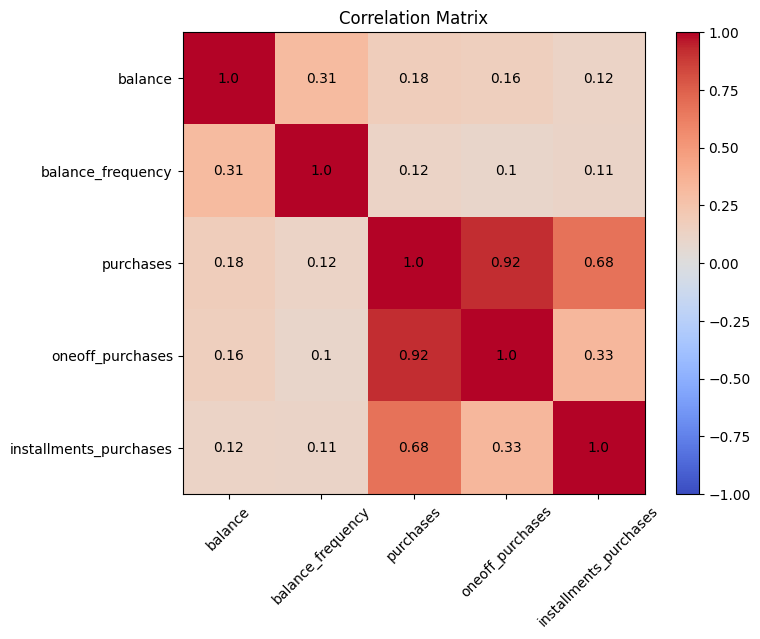

In [ ]:
# features = [
#     'balance',
#     'balance_frequency',
#     'purchases',
#     'oneoff_purchases',
#     'installments_purchases',
#     'cash_advance',
#     'purchases_frequency',
#     'oneoff_purchases_frequency',
#     'purchases_installments_frequency',
#     'cash_advance_frequency',
#     'cash_advance_trx',
#     'purchases_trx',
#     'credit_limit',
#     'payments',
#     'minimum_payments',
#     'prc_full_payment',
#     'tenure'
# ]
#tương quan giữa 
#  balance,
#  balance_frequency, purchases,
#  oneoff_purchases,
#  installments_purchases
features = [
    'balance',
    'balance_frequency','purchases',
    'oneoff_purchases',
    'installments_purchases',]
draw_correlation_matrix(data, features)

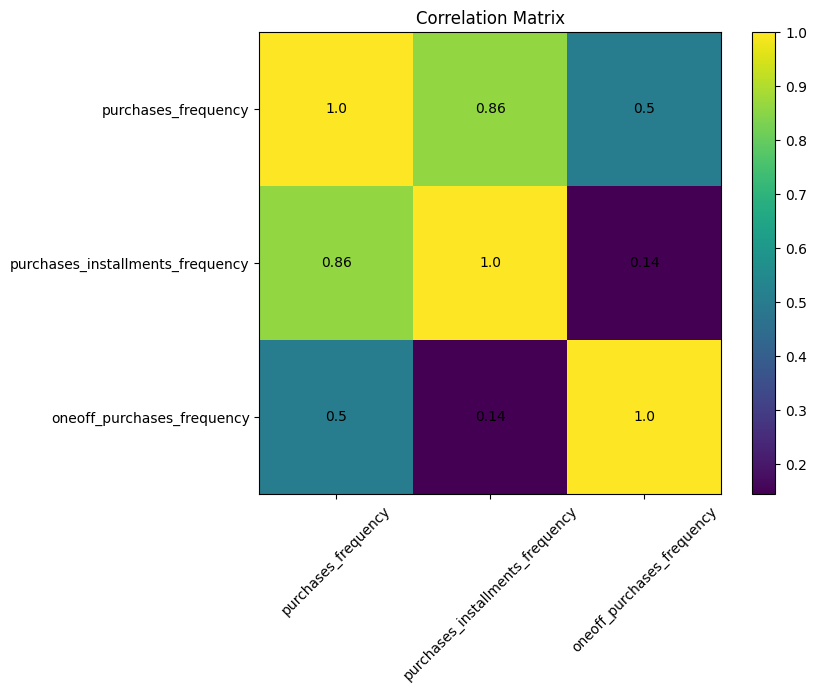

In [ ]:
# tương quan giữa 
# purchases_installments_frequency, 
# purchases_frequency, 
# oneoff_purchases_frequency
features = [
    'purchases_frequency',
    'purchases_installments_frequency','oneoff_purchases_frequency',
    ]
draw_correlation_matrix(data, features)

In [381]:
#xử lí dữ liệu nan trống đó
# print(data[['minimum_payments', 'credit_limit']].isnull().sum())
# data['minimum_payments'] = data['minimum_payments'].fillna(data['minimum_payments'].median())
# data['credit_limit'] = data['credit_limit'].fillna(data['credit_limit'].median())
# print(data[['minimum_payments', 'credit_limit']].isnull().sum())
data.dropna(inplace=True)

In [382]:
#xoá các cột không cần thiết
columns_to_drop = ['cust_id']
data = data.drop(columns=columns_to_drop)
print(data.head(0))

Empty DataFrame
Columns: [balance, balance_frequency, purchases, oneoff_purchases, installments_purchases, cash_advance, purchases_frequency, oneoff_purchases_frequency, purchases_installments_frequency, cash_advance_frequency, cash_advance_trx, purchases_trx, credit_limit, payments, minimum_payments, prc_full_payment, tenure]
Index: []


In [3]:
def plot_box_hist(data, column):
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    plt.boxplot(data[column])
    plt.title(f'Boxplot of {column}')
    
    plt.subplot(1,2,2)
    plt.hist(data[column]      , bins=40, color=random.choice(['blue', 'orange', 'green', 'red', 'purple']))
    plt.title(f'Distribution of {column}')
    
    plt.show()

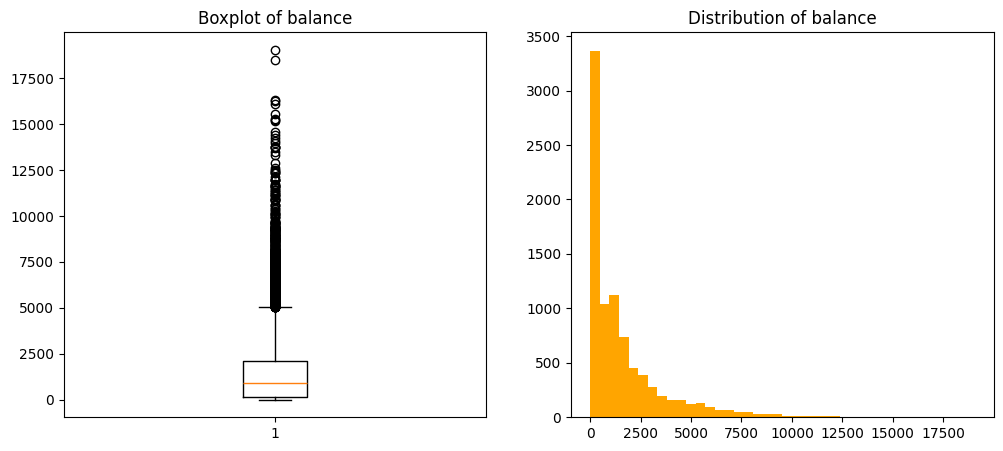

In [384]:
#boxplot và phân phối của balance
plot_box_hist(data, 'balance')

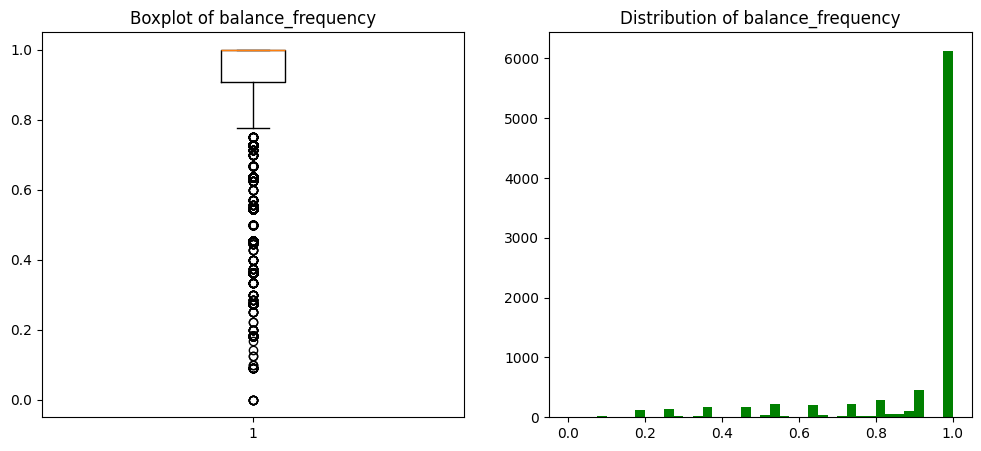

In [385]:
#boxplot và phân phối của balance_frequency
plot_box_hist(data, 'balance_frequency')

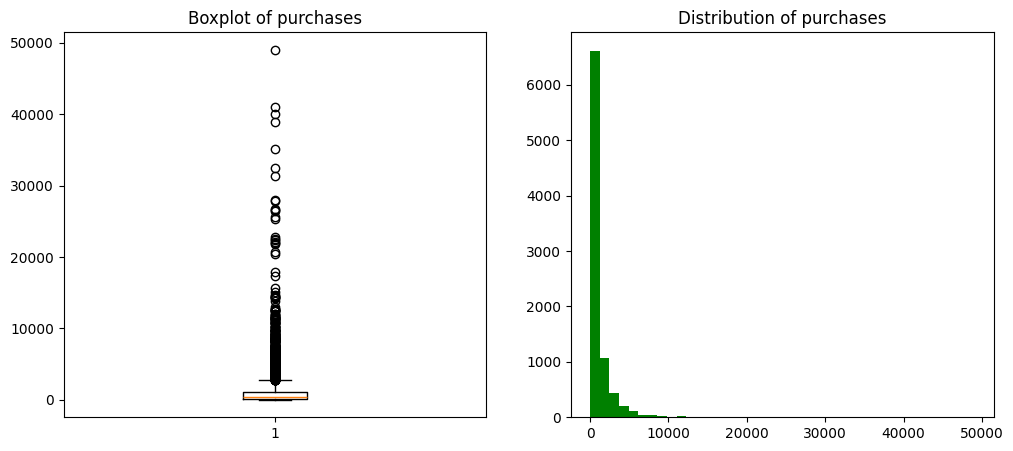

In [386]:
#boxplot và phân phối của purchases
plot_box_hist(data, 'purchases')

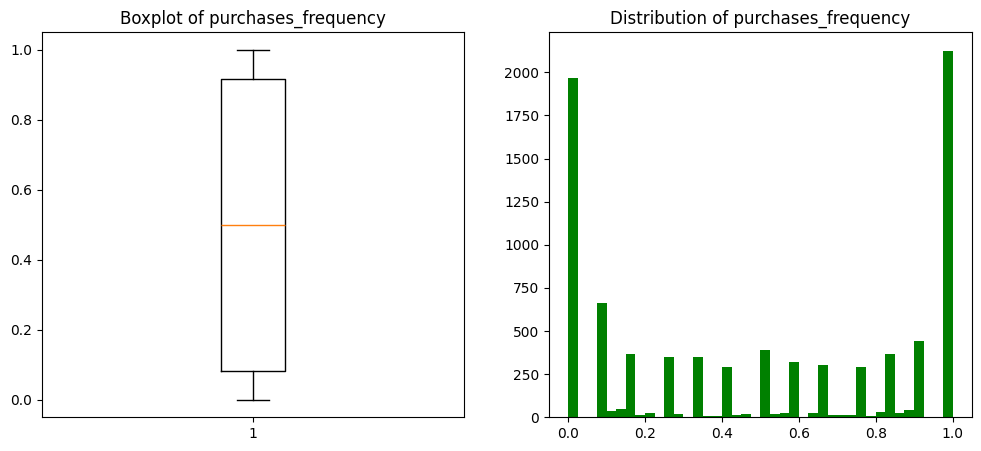

In [387]:
#boxplot và phân phối của purchases_frequency
plot_box_hist(data, 'purchases_frequency')

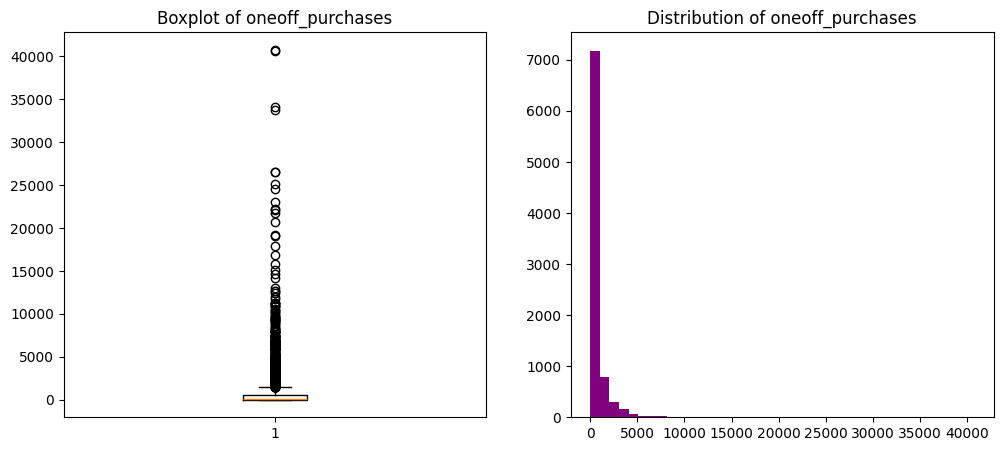

In [388]:
#boxplot và phân phối của oneoff_purchases
plot_box_hist(data, 'oneoff_purchases')

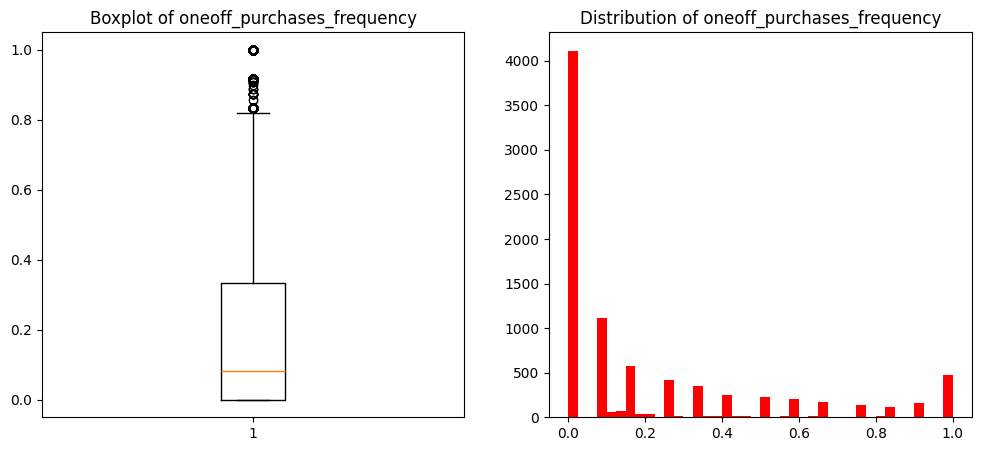

In [389]:
#boxplot và phân phối của oneoff_purchases_frequency
plot_box_hist(data, 'oneoff_purchases_frequency')

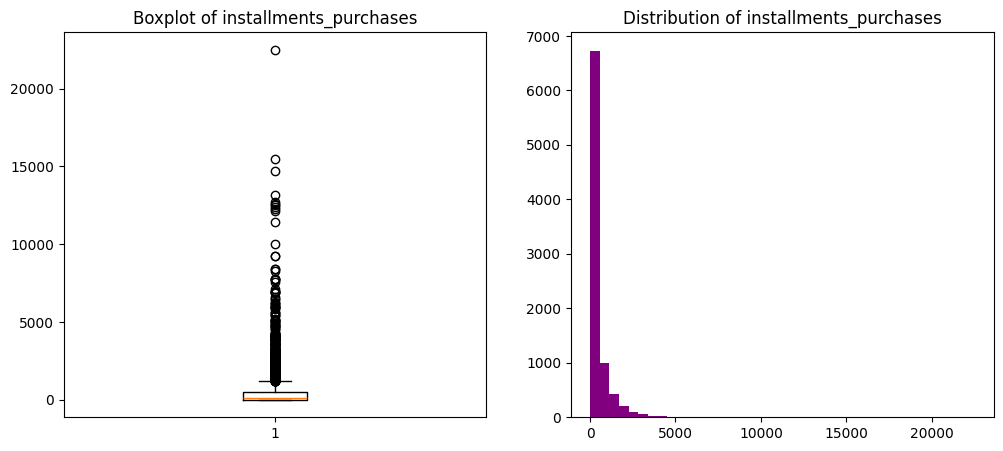

In [390]:
#boxplot và phân phối của installments_purchases
plot_box_hist(data, 'installments_purchases')

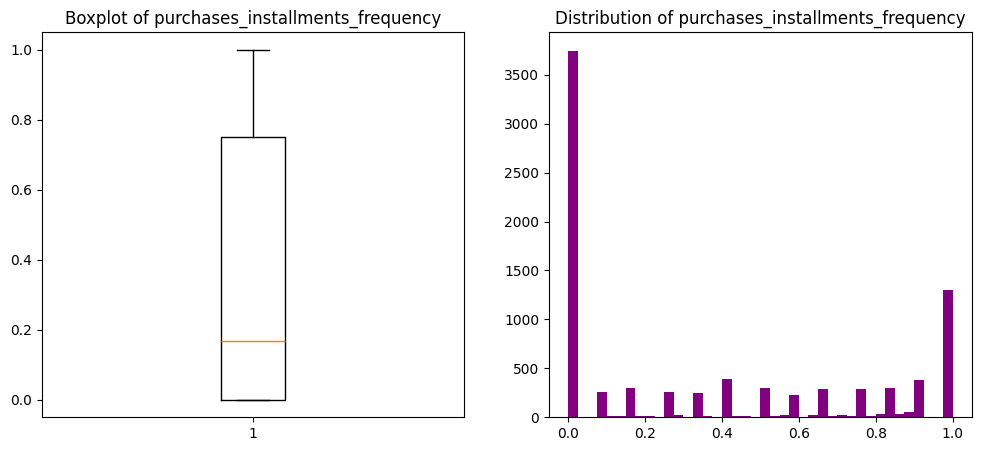

In [391]:
#purchases_installments_frequency
plot_box_hist(data, 'purchases_installments_frequency')

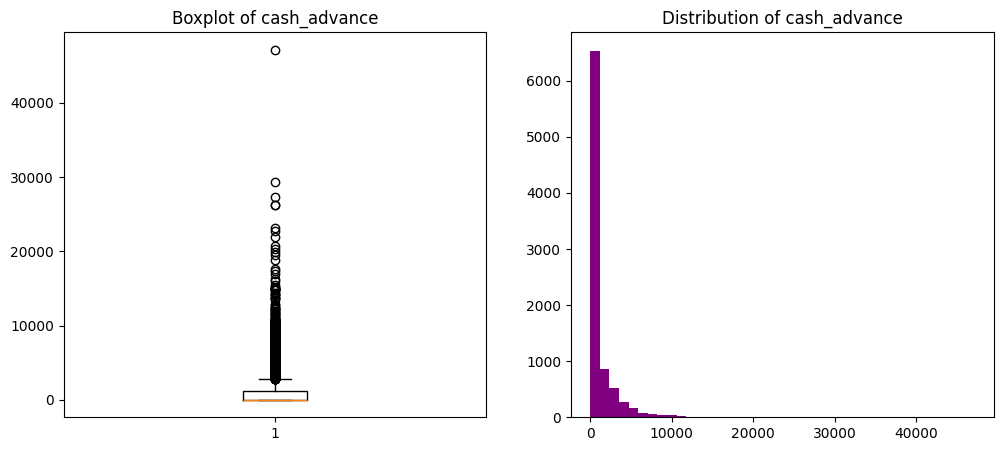

In [392]:
#cash_advance
plot_box_hist(data, 'cash_advance')

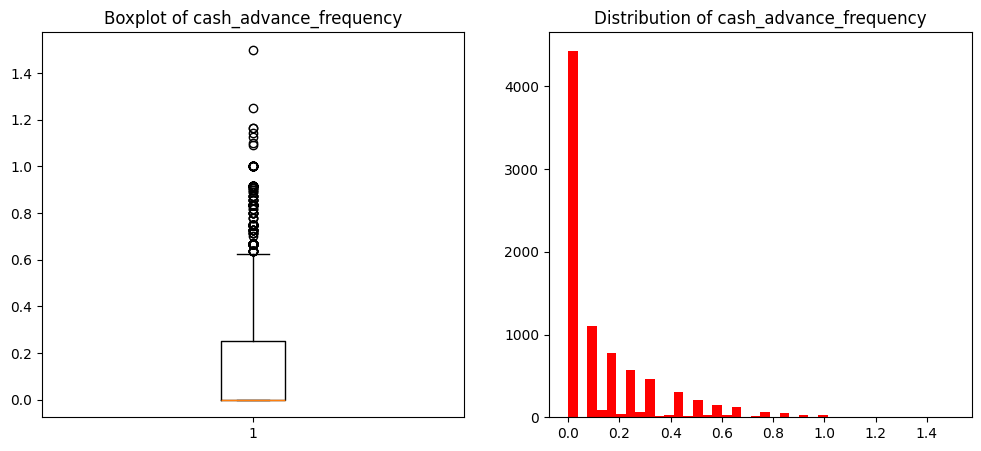

In [393]:
#cash_advance_frequency
plot_box_hist(data, 'cash_advance_frequency')

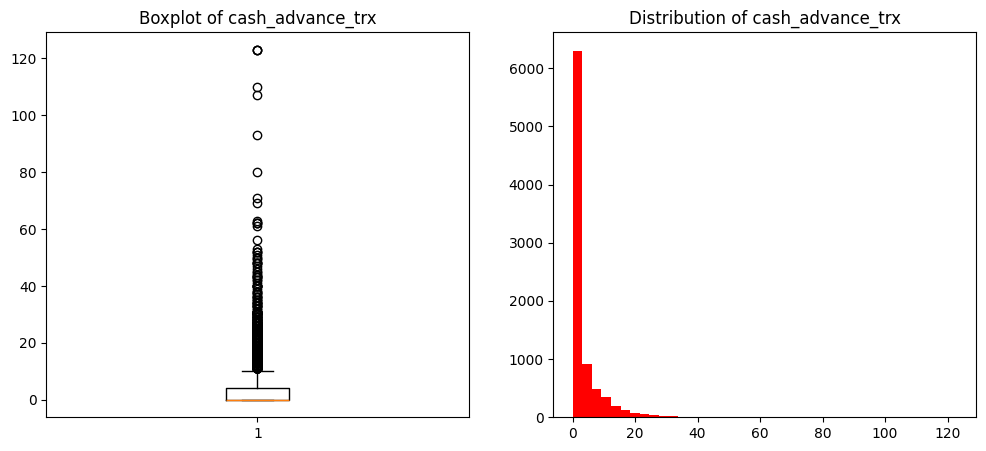

In [394]:
#cash_advance_trx
plot_box_hist(data, 'cash_advance_trx')

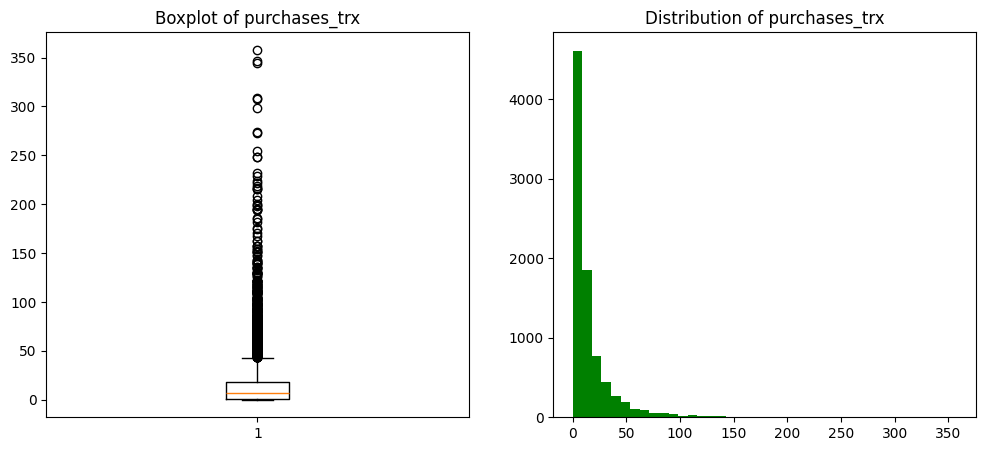

In [395]:
#purchases_trx
plot_box_hist(data, 'purchases_trx')

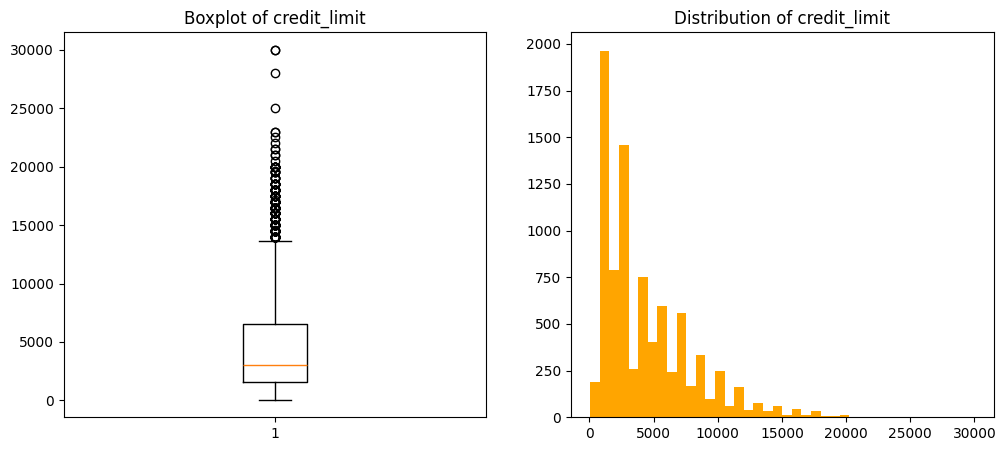

In [396]:
#credit_limit
plot_box_hist(data, 'credit_limit')

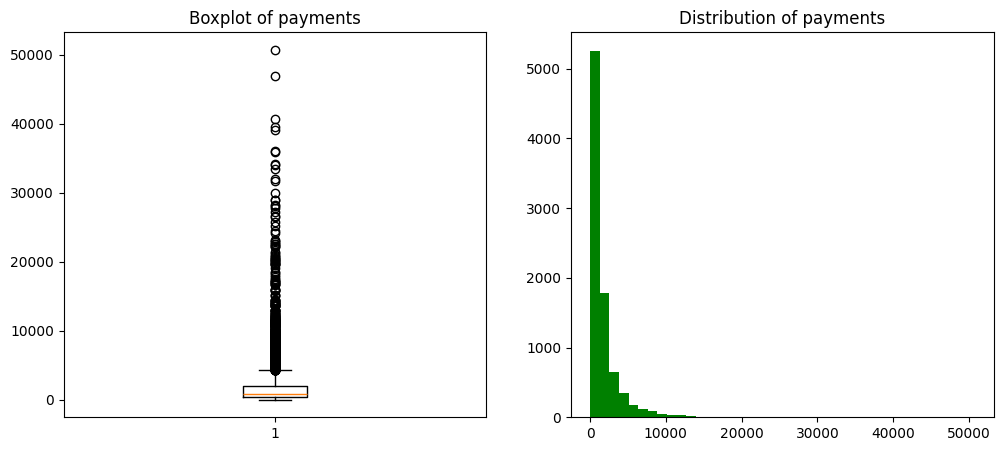

In [397]:
#payments
plot_box_hist(data, 'payments')

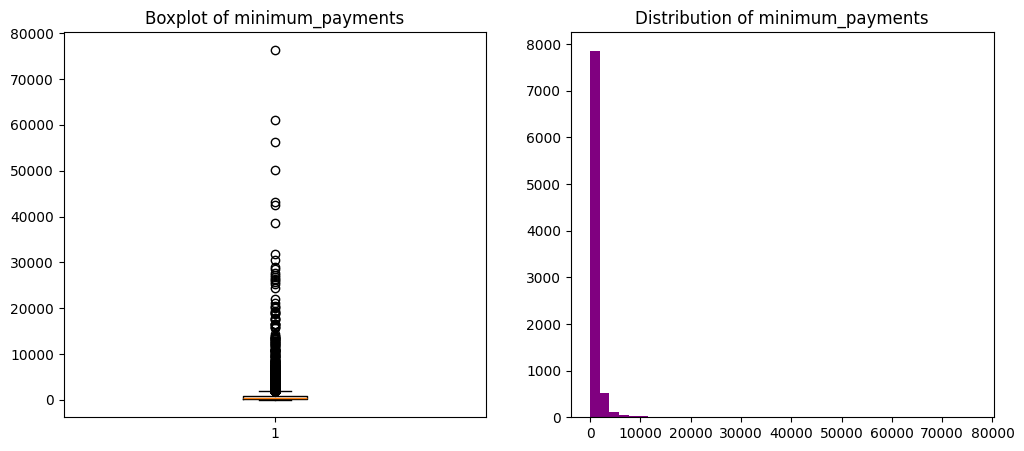

In [398]:
#minimum_payments
plot_box_hist(data, 'minimum_payments')

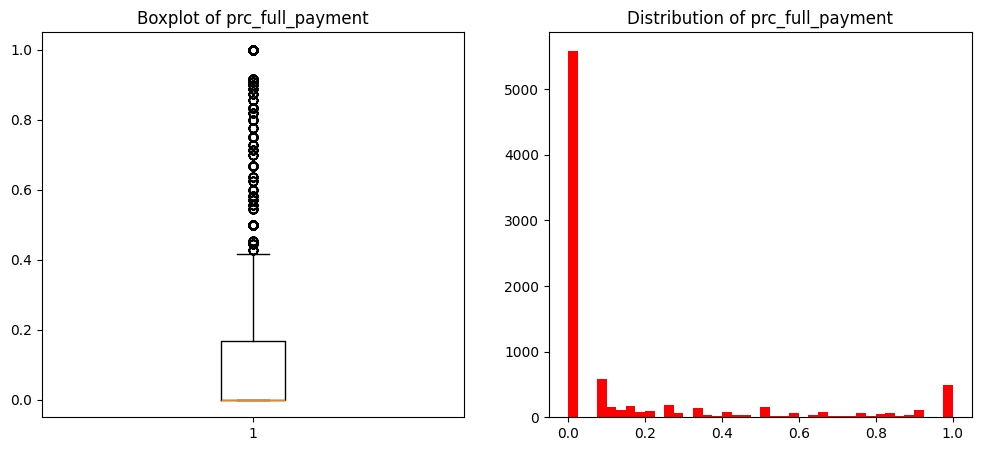

In [399]:
#prc_full_payment
plot_box_hist(data, 'prc_full_payment')

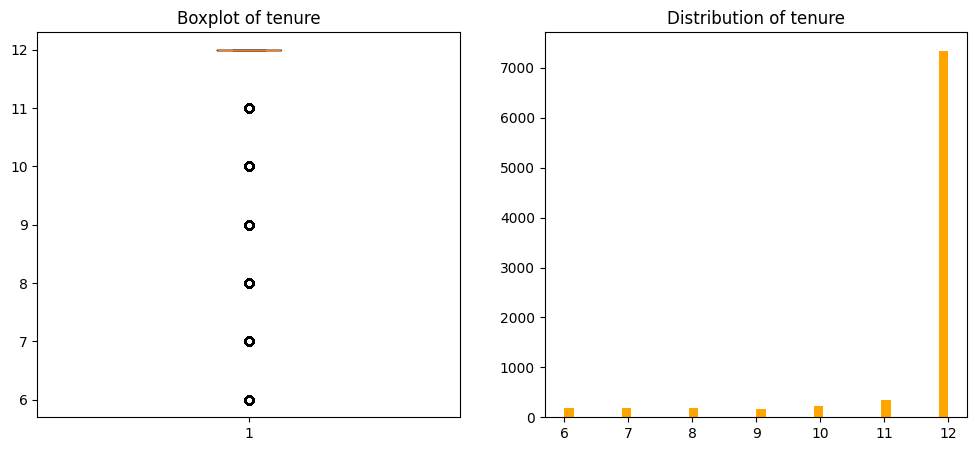

In [400]:
#tenure
plot_box_hist(data, 'tenure')

In [ ]:
#chuẩn hoá dữ liệu bằng standard scaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
scaled_data = pd.DataFrame(scaled_data, columns=data.columns)